Loading flood data...
Aggregating sensor data...
Fetching NYC basemap...
Plotting map...
Figure saved as nyc_all_sensors_map_projected.png!


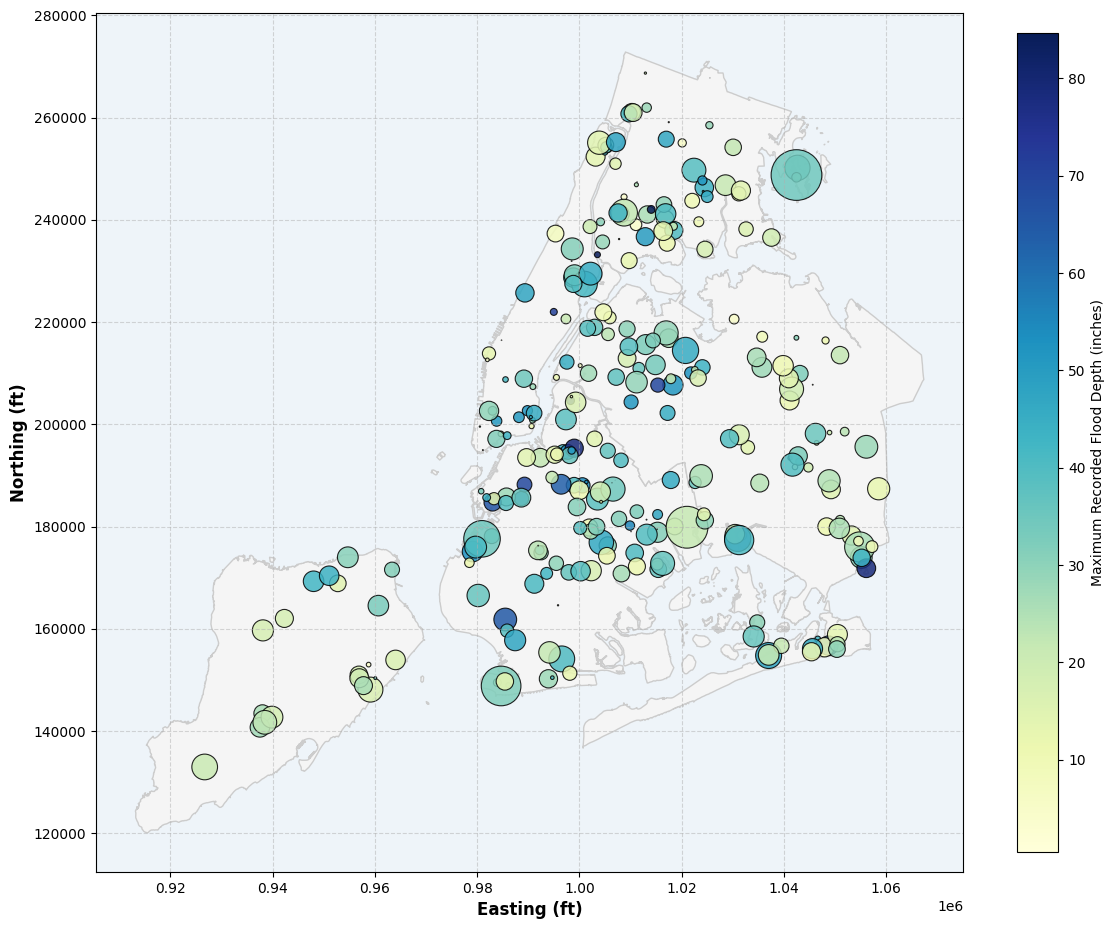

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

print("Loading flood data...")
# 1. Load the new dataset containing ALL sensors
df_floods = pd.read_parquet('floodnet_floods_only.parquet')

print("Aggregating sensor data...")
sensor_stats = df_floods.groupby(['deployment_id', 'name', 'latitude', 'longitude']).agg(
    max_depth_inches=('depth_inches', 'max'),
    total_flood_minutes=('depth_inches', 'count') 
).reset_index()

# Convert to a GeoDataFrame (Initially in standard GPS EPSG:4326)
gdf_sensors = gpd.GeoDataFrame(
    sensor_stats, 
    geometry=gpd.points_from_xy(sensor_stats.longitude, sensor_stats.latitude),
    crs="EPSG:4326" 
)

print("Fetching NYC basemap...")
nyc_url = "https://data.cityofnewyork.us/resource/gthc-hcne.geojson"
nyc_map = gpd.read_file(nyc_url)

# ---------------------------------------------------------
# PROJECTION UPDATE: Convert everything to NY State Plane (Feet)
# ---------------------------------------------------------
nyc_map = nyc_map.to_crs("EPSG:2263")
gdf_sensors = gdf_sensors.to_crs("EPSG:2263")

print("Plotting map...")
fig, ax = plt.subplots(figsize=(12, 12))

# Add the light blue "water" background
ax.set_facecolor('#eef4f9')

# Plot the base map (NYC Boroughs)
nyc_map.plot(
    ax=ax, 
    color='#f5f5f5',      # Very light grey landmass
    edgecolor='#cccccc',  # Subtle borders
    linewidth=1.0
)

# Plot the sensor data on top
scatter = gdf_sensors.plot(
    ax=ax,
    column='max_depth_inches',
    cmap='YlGnBu',                 
    markersize=gdf_sensors['total_flood_minutes'] / 200, 
    alpha=0.85,                     
    edgecolor='black',
    linewidth=0.8,
    legend=True,
    legend_kwds={
        'label': "Maximum Recorded Flood Depth (inches)",
        'orientation': "vertical",
        'shrink': 0.7
    }
)

# ---------------------------------------------------------
# AESTHETICS: Grid lines and Axis Labels
# ---------------------------------------------------------
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlabel("Easting (ft)", fontweight='bold', fontsize=12)
ax.set_ylabel("Northing (ft)", fontweight='bold', fontsize=12)

# Adjust layout and save
plt.tight_layout()
plt.savefig('nyc_all_sensors_map_projected.png', dpi=300, bbox_inches='tight')
print("Figure saved as nyc_all_sensors_map_projected.png!")

plt.show()